<a href="https://www.kaggle.com/code/adegbaju/deepfake-detection-2026-end-to-end-ml-pipeline?scriptVersionId=325048904" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🔍 Deepfake Detection with EfficientNet & Transfer Learning (2026 Dataset)

#  Introduction

With AI‑generated faces becoming nearly indistinguishable from real ones, robust detection models are essential.  
This notebook uses the **Deepfake Detection Dataset 2026** – 6,557 face images (2,790 real from Unsplash, 3,767 fake from StyleGAN3) – to train a binary classifier.

**Dataset features:**
- Pre‑split into train (70%), validation (10%), test (20%)
- Metadata: gender, age group, image quality, detection difficulty
- Ready‑made `FINAL_DATASET.csv` with URLs and labels

We will:
- Perform exploratory data analysis (EDA)
- Load and preprocess images
- Fine‑tune an EfficientNetB0 model
- Evaluate performance with ROC‑AUC, confusion matrix, and per‑difficulty metrics
- Visualise model decisions using Grad‑CAM


#  Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
import zipfile
import shutil
import json
from tqdm import tqdm
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, preprocessing
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-06-06 19:19:14.721970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780773554.888635      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780773554.938142      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780773555.349199      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780773555.349232      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780773555.349235      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


#  Load Dataset & Initial Look

In [2]:
CSV_PATH = '/kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv'
IMAGE_DIR = '/kaggle/working/images'
os.makedirs(IMAGE_DIR, exist_ok=True)
df = pd.read_csv(CSV_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6557, 17)


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,2026-04-24,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,2026-04-04,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,2026-02-07,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-02-20,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,2026-04-12,v2.0,2026


## Check available columns

In [3]:

df.columns.tolist()

['image_id',
 'image_url',
 'label',
 'label_numeric',
 'category',
 'gender',
 'age_group',
 'source',
 'fake_method',
 'image_quality',
 'resolution',
 'confidence_score',
 'detection_difficulty',
 'dataset_split',
 'date_collected',
 'version',
 'year']

# Exploratory Data Analysis (EDA)

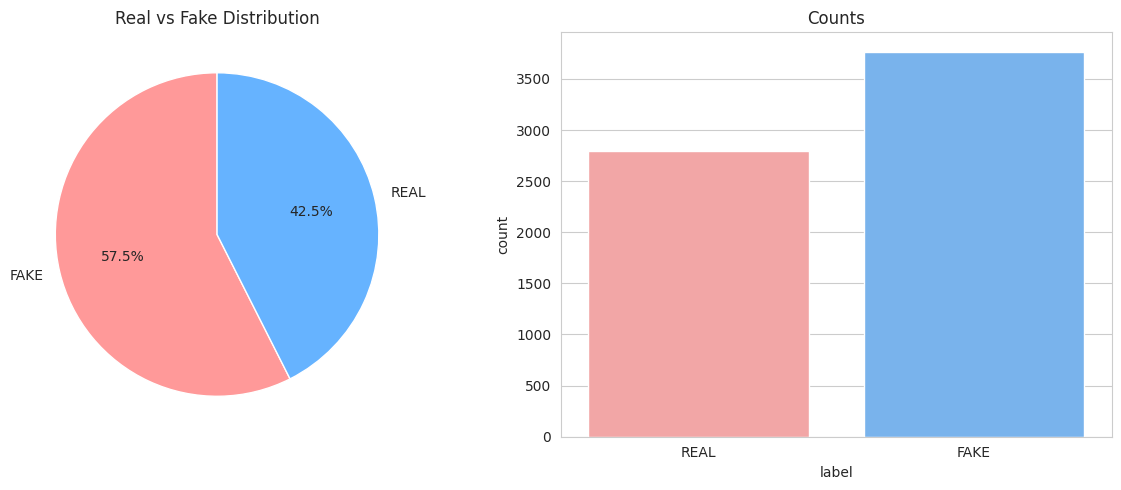

In [4]:

# Distribution of real vs fake
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], startangle=90,
                                     colors=['#ff9999','#66b3ff'])
axes[0].set_ylabel('')
axes[0].set_title('Real vs Fake Distribution')
sns.countplot(data=df, x='label', ax=axes[1], palette=['#ff9999','#66b3ff'])
axes[1].set_title('Counts')
plt.tight_layout()
plt.show()

## Demographic and quality splits

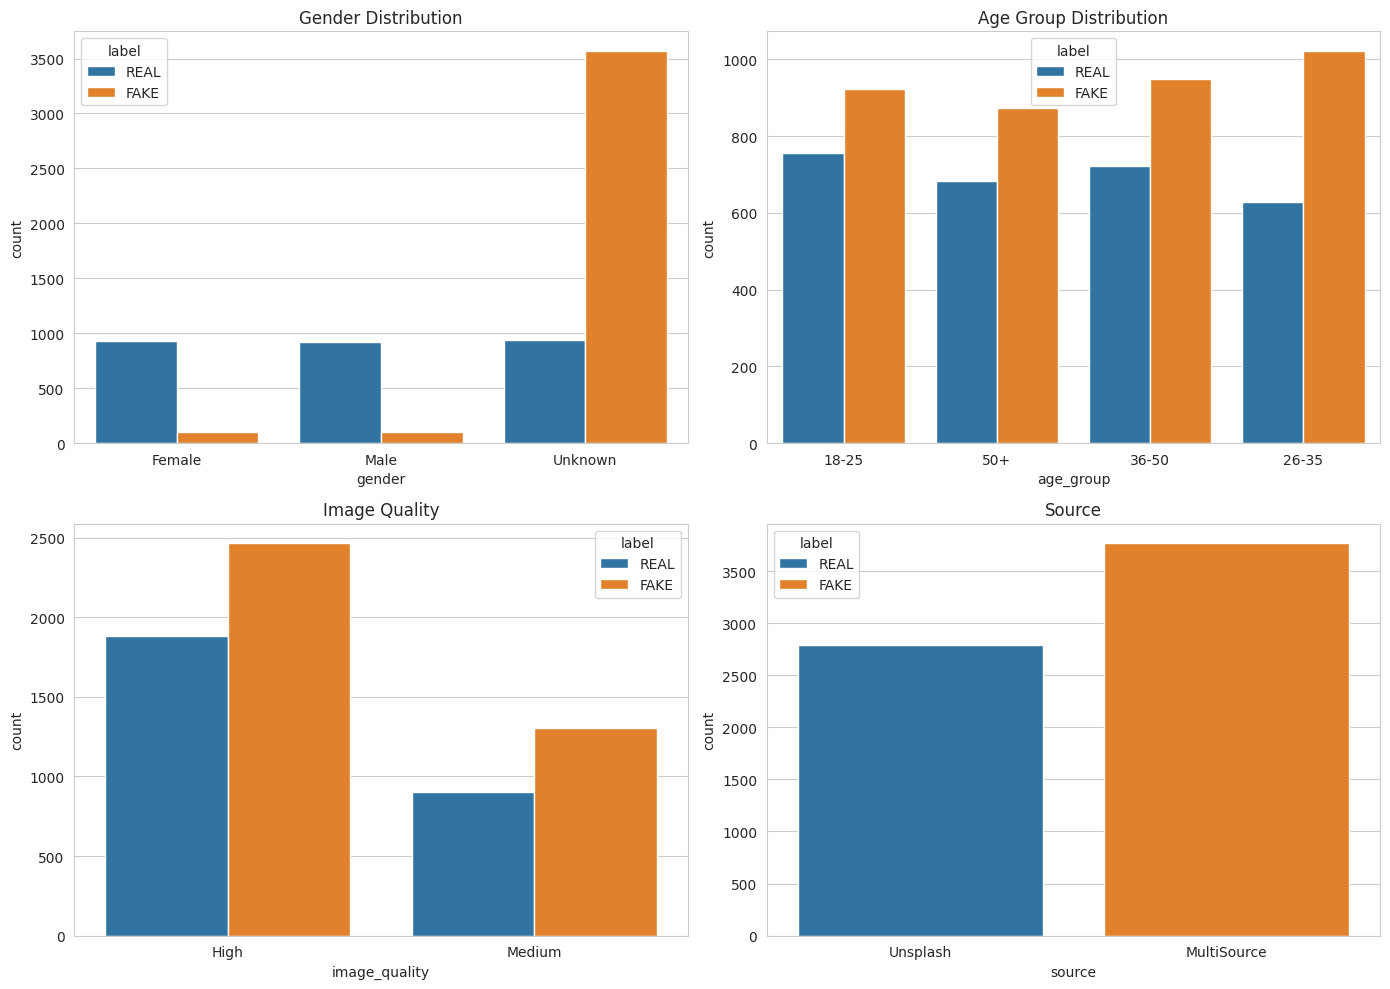

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
sns.countplot(data=df, x='gender', hue='label', ax=axes[0,0])
axes[0,0].set_title('Gender Distribution')
# Age group
sns.countplot(data=df, x='age_group', hue='label', ax=axes[0,1])
axes[0,1].set_title('Age Group Distribution')
# Image quality
sns.countplot(data=df, x='image_quality', hue='label', ax=axes[1,0])
axes[1,0].set_title('Image Quality')
# Source
sns.countplot(data=df, x='source', hue='label', ax=axes[1,1])
axes[1,1].set_title('Source')

plt.tight_layout()
plt.show()

In [6]:
# Basic statistics
print("\n--- Label Distribution ---")
print(df['label'].value_counts(normalize=True))

print("\n--- Gender Distribution ---")
print(df['gender'].value_counts(normalize=True))

print("\n--- Age Group Distribution ---")
print(df['age_group'].value_counts(normalize=True))

print("\n--- Image Quality (if exists) ---")
if 'image_quality' in df.columns:
    print(df['image_quality'].value_counts(normalize=True))

# Check for difficulty column (mentioned in dataset description)
if 'detection_difficulty' in df.columns:
    print("\n--- Detection Difficulty ---")
    print(df['detection_difficulty'].value_counts(normalize=True))


--- Label Distribution ---
label
FAKE    0.574501
REAL    0.425499
Name: proportion, dtype: float64

--- Gender Distribution ---
gender
Unknown    0.687357
Female     0.157542
Male       0.155101
Name: proportion, dtype: float64

--- Age Group Distribution ---
age_group
18-25    0.256367
36-50    0.254690
26-35    0.251639
50+      0.237304
Name: proportion, dtype: float64

--- Image Quality (if exists) ---
image_quality
High      0.663413
Medium    0.336587
Name: proportion, dtype: float64

--- Detection Difficulty ---
detection_difficulty
Easy      0.425499
Hard      0.375324
Medium    0.199176
Name: proportion, dtype: float64


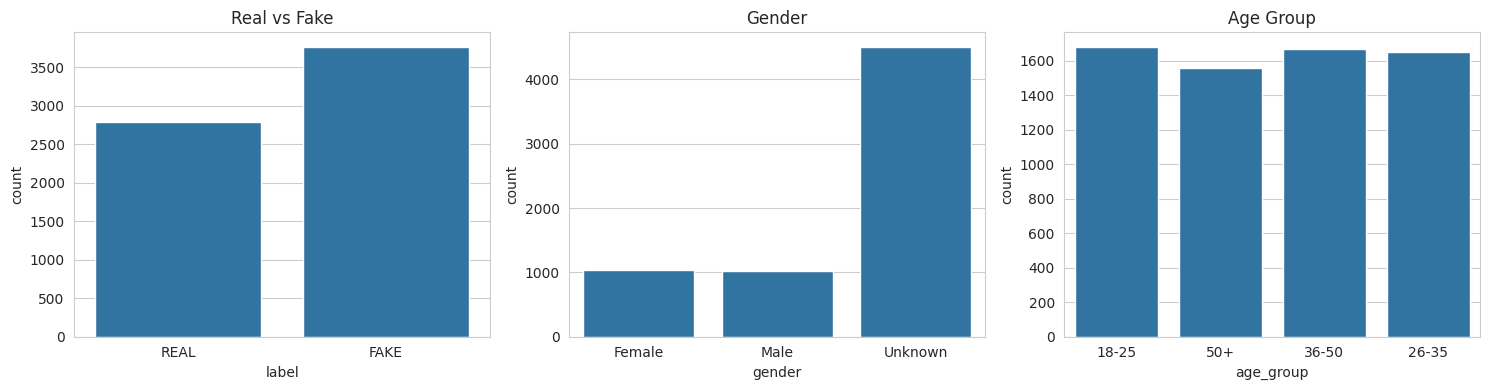

In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='label', ax=axes[0])
axes[0].set_title('Real vs Fake')
sns.countplot(data=df, x='gender', ax=axes[1])
axes[1].set_title('Gender')
sns.countplot(data=df, x='age_group', ax=axes[2])
axes[2].set_title('Age Group')
plt.tight_layout()
plt.show()

#  Download Images (Local Cache)

In [8]:
DOWNLOAD_LOG = '/kaggle/working/downloaded.txt'
FAILED_LOG = '/kaggle/working/failed_urls.txt'

def download_image(url, save_path, timeout=10):
    """Download an image from URL and save it. Return True on success."""
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.convert('RGB')          # ensure RGB
        img.save(save_path, 'JPEG')
        return True
    except Exception as e:
        return False

# Already downloaded set
downloaded = set()
if os.path.exists(DOWNLOAD_LOG):
    with open(DOWNLOAD_LOG, 'r') as f:
        downloaded = set(line.strip() for line in f)

# Filter out already downloaded
to_download = df[~df['image_id'].astype(str).isin(downloaded)]

print(f"Already downloaded: {len(downloaded)}")
print(f"Images to download: {len(to_download)}")

if len(to_download) > 0:
    failed_urls = []
    for idx, row in tqdm(to_download.iterrows(), total=len(to_download), desc="Downloading"):
        img_id = str(row['image_id'])
        img_url = row['image_url']
        save_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")
        success = download_image(img_url, save_path)
        if success:
            with open(DOWNLOAD_LOG, 'a') as f:
                f.write(f"{img_id}\n")
        else:
            failed_urls.append(img_url)
    # Save failed URLs for later inspection
    with open(FAILED_LOG, 'w') as f:
        for url in failed_urls:
            f.write(url + '\n')
    print(f"Download finished. Failed: {len(failed_urls)}")
else:
    print("All images already downloaded.")

Already downloaded: 0
Images to download: 6557


Downloading: 100%|██████████| 6557/6557 [09:07<00:00, 11.98it/s]

Download finished. Failed: 1000


In [9]:
# Build list of successfully downloaded image IDs
downloaded_ids = []
if os.path.exists(DOWNLOAD_LOG):
    with open(DOWNLOAD_LOG, 'r') as f:
        downloaded_ids = [line.strip() for line in f]

df_clean = df[df['image_id'].astype(str).isin(downloaded_ids)].copy()
df_clean['image_path'] = df_clean['image_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))

print(f"Original: {len(df)}  ->  Usable: {len(df_clean)}")

Original: 6557  ->  Usable: 5557


# Build TensorFlow Pipeline

In [10]:
# Use provided split if available, else create stratified split
if 'split' in df_clean.columns:
    train_df = df_clean[df_clean['split'] == 'train']
    val_df = df_clean[df_clean['split'] == 'val']
    test_df = df_clean[df_clean['split'] == 'test']
else:
    # Stratified split: 70% train, 20% val, 10% test
    train_df, temp_df = train_test_split(df_clean, test_size=0.3, stratify=df_clean['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.333, stratify=temp_df['label'], random_state=42)  # 0.333*0.3≈0.1

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 3889 | Val: 1112 | Test: 556


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0   # normalize to [0,1]
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_numeric'].values))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label_numeric'].values))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_numeric'].values))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1780774117.288964      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780774117.295151      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Model Architecture (EfficientNetB0) 

In [12]:
# Class weights: compute from training set
neg, pos = np.bincount(train_df['label_numeric'])
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"Class weights: {class_weight}")

base_model = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
base_model.trainable = False   # freeze base

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.AUC()]
)

model.summary()

Class weights: {0: np.float64(1.0043904958677685), 1: np.float64(0.995647721454173)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Training & Callbacks 

In [13]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20


I0000 00:00:1780774133.039809      74 service.cc:152] XLA service 0x7d619c015d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780774133.039842      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780774133.039846      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780774135.440201      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 19:29:02.301854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:02.444904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:02.780169: E external/local_xl

120/122 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5100 - auc: 0.5018 - loss: 0.6989 - precision: 0.5146 - recall: 0.4678

2026-06-06 19:29:23.016310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:23.155961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:23.471282: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:23.611492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:29:24.402780: E external/local_xla/xla/stream_

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5100 - auc: 0.5020 - loss: 0.6989 - precision: 0.5146 - recall: 0.4680

...


Epoch 1: val_accuracy improved from None to 0.49820, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 67s 323ms/step - accuracy: 0.5122 - auc: 0.5092 - loss: 0.6975 - precision: 0.5156 - recall: 0.4741 - val_accuracy: 0.4982 - val_auc: 0.7069 - val_loss: 0.6935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4947 - auc: 0.4999 - loss: 0.6963 - precision: 0.5066 - recall: 0.5139
Epoch 2: val_accuracy did not improve from 0.49820
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5035 - auc: 0.5115 - loss: 0.6952 - precision: 0.5060 - recall: 0.4772 - val_accuracy: 0.4982 - val_auc: 0.8223 - val_loss: 0.6912 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5057 - auc: 0.5044 - loss: 0.6974 - precision: 0.5094 - recall: 0.5358
Epoch 3: val_accuracy improved from 0.49820 to 0.50180, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.5102 - auc: 0.5110 - loss: 0.6966 - precision: 0.5125 - recall: 0.5049 - val_accuracy: 0.5018 - val_auc: 0.7775 - val_loss: 0.6967 - val_precision: 0.5018 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5114 - auc: 0.5220 - loss: 0.6935 - precision: 0.5159 - recall: 0.6496
Epoch 4: val_accuracy did not improve from 0.50180
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5130 - auc: 0.5210 - loss: 0.6938 - precision: 0.5141 - recall: 0.5494 - val_accuracy: 0.4982 - val_auc: 0.8197 - val_loss: 0.6973 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5134 - auc: 0.5221 - loss: 0.6966 - precision: 0.5289 - recall: 0.5140
Epoch 5: val_accuracy improved from 0.50180 to 0.79406, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.5107 - auc: 0.5170 - loss: 0.6984 - precision: 0.5135 - recall: 0.4859 - val_accuracy: 0.7941 - val_auc: 0.8585 - val_loss: 0.6881 - val_precision: 0.8852 - val_recall: 0.6774 - learning_rate: 0.0010
Epoch 6/20
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5208 - auc: 0.5319 - loss: 0.6913 - precision: 0.5286 - recall: 0.6313
Epoch 6: val_accuracy did not improve from 0.79406
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5192 - auc: 0.5296 - loss: 0.6936 - precision: 0.5204 - recall: 0.5417 - val_accuracy: 0.4982 - val_auc: 0.8594 - val_loss: 0.6894 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5033 - auc: 0.5146 - loss: 0.6956 - precision: 0.5056 - recall: 0.4651
Epoch 7: val_accuracy did not improve from 0.79406
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accura


Epoch 11: finished saving model to best_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.5163 - auc: 0.5291 - loss: 0.6922 - precision: 0.5188 - recall: 0.5090 - val_accuracy: 0.8004 - val_auc: 0.8638 - val_loss: 0.6866 - val_precision: 0.8784 - val_recall: 0.6989 - learning_rate: 2.0000e-04
Epoch 12/20
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5323 - auc: 0.5514 - loss: 0.6889 - precision: 0.5343 - recall: 0.6179
Epoch 12: val_accuracy did not improve from 0.80036
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5228 - auc: 0.5344 - loss: 0.6919 - precision: 0.5238 - recall: 0.5469 - val_accuracy: 0.5782 - val_auc: 0.8658 - val_loss: 0.6867 - val_precision: 0.9406 - val_recall: 0.1703 - learning_rate: 2.0000e-04
Epoch 13/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5624 - auc: 0.5747 - loss: 0.6863 - precision: 0.5611 - recall: 0.6428
Epoch 13: val_accuracy did not improve from 0.80036
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - a

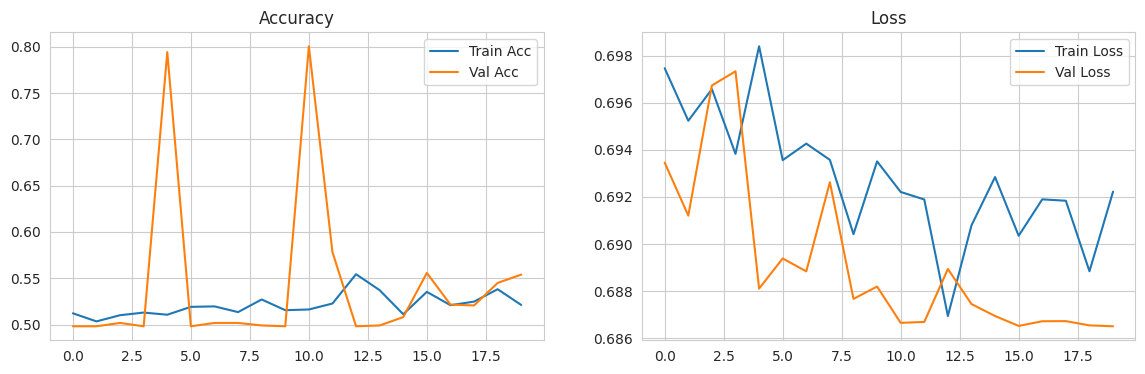

In [14]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(hist.history['accuracy'], label='Train Acc')
    axes[0].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    axes[1].plot(hist.history['loss'], label='Train Loss')
    axes[1].plot(hist.history['val_loss'], label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].legend()
    plt.show()

plot_history(history)

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

2026-06-06 19:33:12.167092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:12.304376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:12.614618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:12.754865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:13.508867: E external/local_xla/xla/stream_

18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 718ms/step
              precision    recall  f1-score   support

        FAKE       0.75      0.92      0.83       277
        REAL       0.89      0.70      0.79       279

    accuracy                           0.81       556
   macro avg       0.82      0.81      0.81       556
weighted avg       0.82      0.81      0.81       556

ROC-AUC: 0.9065


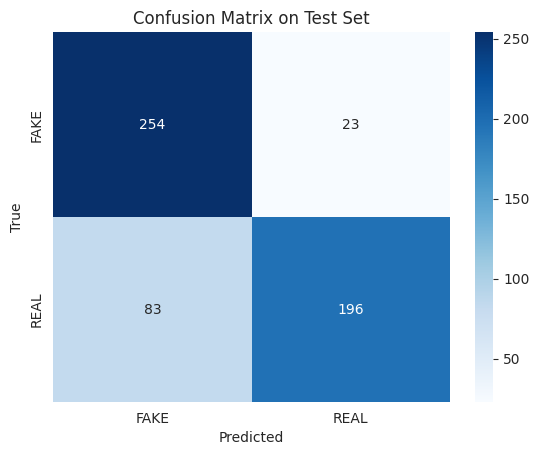

In [15]:
# Load best model
model.load_weights('best_model.h5')

# Predict on test set
y_true = test_df['label_numeric'].values
y_pred_prob = model.predict(test_ds).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
print(classification_report(y_true, y_pred, target_names=['FAKE', 'REAL']))
auc = roc_auc_score(y_true, y_pred_prob)
print(f"ROC-AUC: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Bias & Fairness Analysis 

In [16]:
def evaluate_subgroup(df_subset, subgroup_name):
    if len(df_subset) == 0:
        print(f"No samples for {subgroup_name}")
        return
    # Create dataset for this subgroup
    ds = tf.data.Dataset.from_tensor_slices((df_subset['image_path'].values, df_subset['label_numeric'].values))
    ds = ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    y_true_sub = df_subset['label_numeric'].values
    y_pred_sub_prob = model.predict(ds).flatten()
    y_pred_sub = (y_pred_sub_prob >= 0.5).astype(int)
    acc = np.mean(y_true_sub == y_pred_sub)
    auc_sub = roc_auc_score(y_true_sub, y_pred_sub_prob)
    print(f"{subgroup_name}: Accuracy = {acc:.4f}, AUC = {auc_sub:.4f}")
    return acc, auc_sub

print("--- Performance by Gender ---")
for g in df_clean['gender'].unique():
    sub = test_df[test_df['gender'] == g]
    evaluate_subgroup(sub, f"Gender = {g}")

print("\n--- Performance by Age Group ---")
for a in df_clean['age_group'].unique():
    sub = test_df[test_df['age_group'] == a]
    evaluate_subgroup(sub, f"Age = {a}")

if 'image_quality' in df_clean.columns:
    print("\n--- Performance by Image Quality ---")
    for q in df_clean['image_quality'].unique():
        sub = test_df[test_df['image_quality'] == q]
        evaluate_subgroup(sub, f"Quality = {q}")

--- Performance by Gender ---
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

2026-06-06 19:33:22.686808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:22.822661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:23.130377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:23.271333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:24.062488: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
Gender = Female: Accuracy = 0.7087, AUC = 0.6996
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

2026-06-06 19:33:32.167965: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:32.303420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:32.611537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:32.752021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:33:33.529260: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step
Gender = Male: Accuracy = 0.7327, AUC = 0.8015
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Gender = Unknown: Accuracy = 0.8608, AUC = 0.9087

--- Performance by Age Group ---
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Age = 36-50: Accuracy = 0.8385, AUC = 0.9255
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Age = 26-35: Accuracy = 0.8074, AUC = 0.9216

--- Performance by Image Quality ---
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

2026-06-06 19:34:11.984278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:12.119463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:12.426880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:12.567281: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:13.311565: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 857ms/step
Quality = High: Accuracy = 0.8034, AUC = 0.8968
5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

2026-06-06 19:34:21.684114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:21.820287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:22.127315: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:22.267701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:23.040347: E external/local_xla/xla/stream_

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
Quality = Medium: Accuracy = 0.8200, AUC = 0.9249


# Inference on New Images 

In [17]:
def predict_image(image_source, model, img_size=224):
    """
    image_source: file path or URL
    Returns: (label, confidence)
    """
    if image_source.startswith('http'):
        response = requests.get(image_source, timeout=10)
        img = Image.open(BytesIO(response.content))
    else:
        img = Image.open(image_source)
    img = img.convert('RGB')
    img = img.resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prob = model.predict(img_array)[0][0]
    label = "REAL" if prob >= 0.5 else "FAKE"
    return label, prob

# Example: test on a random image from the test set
sample_url = test_df['image_url'].iloc[0]
label, conf = predict_image(sample_url, model)
print(f"Prediction: {label} (confidence: {conf:.4f})")

2026-06-06 19:34:34.305444: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:34.441254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:35.174766: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 19:34:35.310363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: FAKE (confidence: 0.4960)


In [18]:
model.save('deepfake_detector_final.h5')
print("Model saved as deepfake_detector_final.h5")

Model saved as deepfake_detector_final.h5


# Class imbalance across sensitive attributes (bias check)

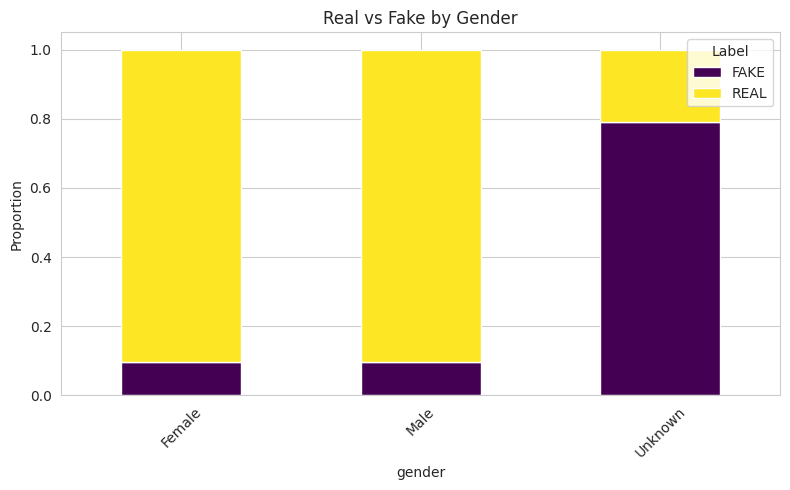

Chi-square test for gender: p = 0.0000 (significant)


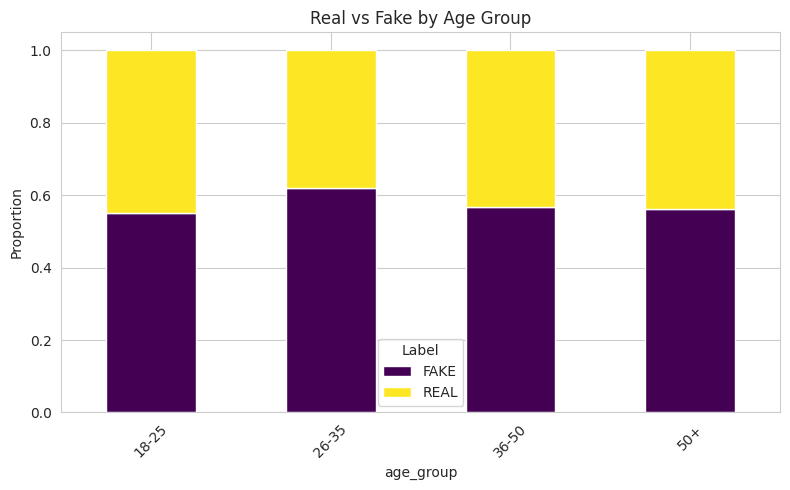

Chi-square test for age_group: p = 0.0002 (significant)


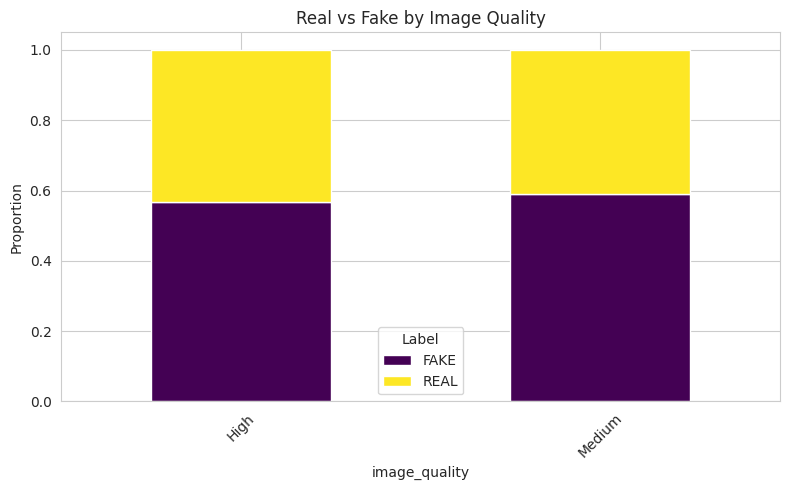

Chi-square test for image_quality: p = 0.0759 (not significant)


In [19]:


def cross_tab_plot(df, col, title):
    ctab = pd.crosstab(df[col], df['label'], normalize='index')
    ctab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
    plt.title(f'Real vs Fake by {title}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()
    # Chi‑square test of independence
    cont_table = pd.crosstab(df[col], df['label'])
    chi2, p, dof, expected = chi2_contingency(cont_table)
    print(f"Chi-square test for {col}: p = {p:.4f} {'(significant)' if p < 0.05 else '(not significant)'}")
    return ctab

# Gender
if 'gender' in df.columns:
    cross_tab_plot(df, 'gender', 'Gender')
# Age group
if 'age_group' in df.columns:
    cross_tab_plot(df, 'age_group', 'Age Group')
# Image quality
if 'image_quality' in df.columns:
    cross_tab_plot(df, 'image_quality', 'Image Quality')


# Fake method distribution


--- Fake Generation Methods ---
fake_method
StyleGAN3    3767
Name: count, dtype: int64


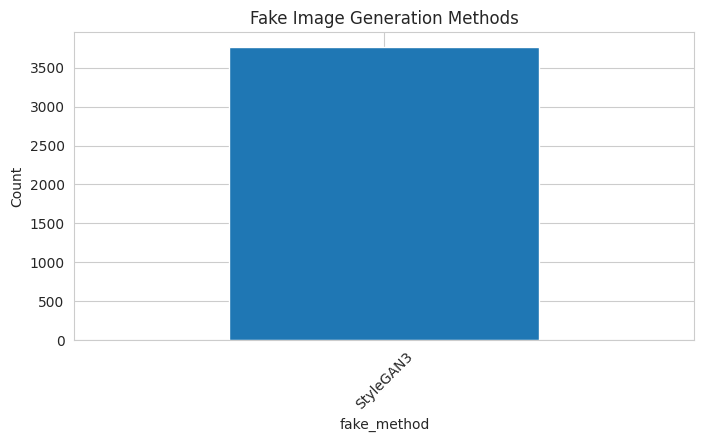

In [20]:
if 'fake_method' in df.columns:
    print("\n--- Fake Generation Methods ---")
    fake_methods = df[df['label'] == 'FAKE']['fake_method'].value_counts()
    print(fake_methods)
    fake_methods.plot(kind='bar', figsize=(8,4), title='Fake Image Generation Methods')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\nColumn 'fake_method' not found. Skipping.")

# Detection difficulty


--- Detection Difficulty Distribution ---
detection_difficulty
Easy      0.425499
Hard      0.375324
Medium    0.199176
Name: proportion, dtype: float64


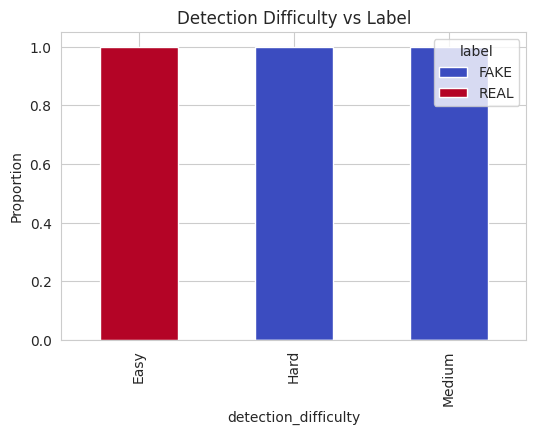

In [21]:
if 'detection_difficulty' in df.columns:
    print("\n--- Detection Difficulty Distribution ---")
    print(df['detection_difficulty'].value_counts(normalize=True))
    ctd = pd.crosstab(df['detection_difficulty'], df['label'], normalize='index')
    ctd.plot(kind='bar', stacked=True, figsize=(6,4), colormap='coolwarm')
    plt.title('Detection Difficulty vs Label')
    plt.ylabel('Proportion')
    plt.show()
else:
    print("\nColumn 'detection_difficulty' not found. (Dataset description mentions it, but might be missing in CSV?)")


# Image pixel statistics

Computing image stats: 100%|██████████| 500/500 [00:00<00:00, 25807.61it/s]


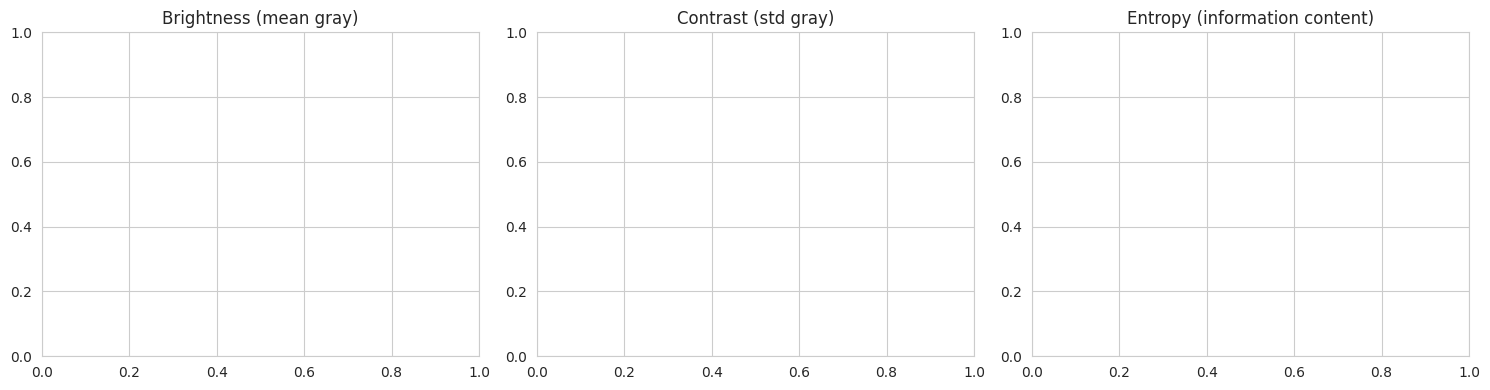

Mann-Whitney U test for brightness: p = nan
Mann-Whitney U test for contrast: p = nan
Mann-Whitney U test for entropy: p = nan


In [22]:
sample_size = min(500, len(df_clean))
sample_images = df_clean.sample(sample_size, random_state=42)

def compute_image_stats(img_path):
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness = np.mean(img_gray)
        contrast = np.std(img_gray)
        # Entropy
        hist = cv2.calcHist([img_gray], [0], None, [256], [0,256])
        hist = hist.flatten() / hist.sum()
        entropy = -np.sum(hist * np.log2(hist + 1e-7))
        return brightness, contrast, entropy
    except:
        return None

stats = []
for _, row in tqdm(sample_images.iterrows(), total=len(sample_images), desc="Computing image stats"):
    res = compute_image_stats(row['image_path'])
    if res:
        stats.append((row['label'], res[0], res[1], res[2]))
        
stats_df = pd.DataFrame(stats, columns=['label', 'brightness', 'contrast', 'entropy'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=stats_df, x='label', y='brightness', ax=axes[0])
axes[0].set_title('Brightness (mean gray)')
sns.boxplot(data=stats_df, x='label', y='contrast', ax=axes[1])
axes[1].set_title('Contrast (std gray)')
sns.boxplot(data=stats_df, x='label', y='entropy', ax=axes[2])
axes[2].set_title('Entropy (information content)')
plt.tight_layout()
plt.show()

# Statistical tests
from scipy.stats import mannwhitneyu
for metric in ['brightness', 'contrast', 'entropy']:
    real = stats_df[stats_df['label']=='REAL'][metric]
    fake = stats_df[stats_df['label']=='FAKE'][metric]
    stat, p = mannwhitneyu(real, fake)
    print(f"Mann-Whitney U test for {metric}: p = {p:.4e}")


# Embedding visualization (PCA / t‑SNE) using a pretrained model

Extracting embeddings: 100%|██████████| 400/400 [01:51<00:00,  3.59it/s]


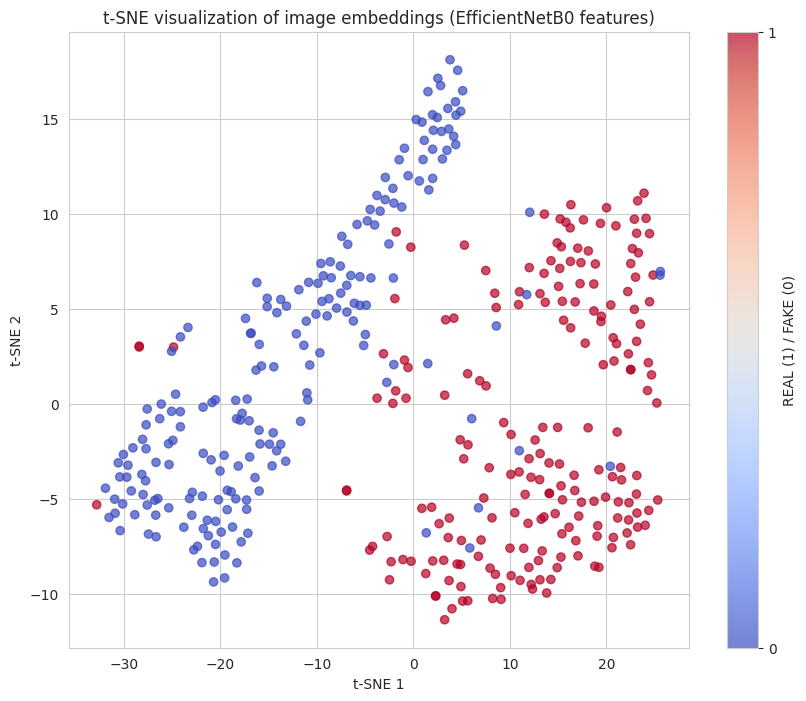

In [23]:

feat_extractor = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
feat_extractor.trainable = False

def get_embedding(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)
    emb = feat_extractor(img, training=False)
    emb = tf.reduce_mean(emb, axis=[1,2])  # global avg pool
    return emb.numpy().flatten()

# Sample a balanced subset for visualization (e.g., 200 real, 200 fake)
vis_sample = pd.concat([
    df_clean[df_clean['label']=='REAL'].sample(200, random_state=42),
    df_clean[df_clean['label']=='FAKE'].sample(200, random_state=42)
])
embeddings = []
for _, row in tqdm(vis_sample.iterrows(), total=len(vis_sample), desc="Extracting embeddings"):
    emb = get_embedding(row['image_path'])
    embeddings.append(emb)

embeddings = np.array(embeddings)
labels = vis_sample['label'].values

# PCA
pca = PCA(n_components=50)
emb_pca = pca.fit_transform(embeddings)
# t‑SNE on top 50 PCA components (faster)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(emb_pca)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(emb_tsne[:,0], emb_tsne[:,1], c=(labels=='REAL').astype(int), cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, ticks=[0,1], label='REAL (1) / FAKE (0)')
plt.title('t‑SNE visualization of image embeddings (EfficientNetB0 features)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# URL / source domain analysis

In [24]:
if 'image_url' in df.columns:
    # Extract domain from URL
    from urllib.parse import urlparse
    df['domain'] = df['image_url'].apply(lambda x: urlparse(x).netloc)
    print("\n--- URL Domains ---")
    print(df['domain'].value_counts().head(10))
    
    # Check for potential duplicates (same URL)
    url_counts = df['image_url'].value_counts()
    duplicate_urls = url_counts[url_counts > 1]
    if len(duplicate_urls) > 0:
        print(f"Found {len(duplicate_urls)} duplicate URLs (should not happen in a clean dataset)")
    else:
        print("No duplicate URLs found.")


--- URL Domains ---
domain
images.unsplash.com    2790
api.dicebear.com       2499
api.multiavatar.com    1000
randomuser.me           198
i.pravatar.cc            70
Name: count, dtype: int64
No duplicate URLs found.


# Correlation matrix of numeric metadata

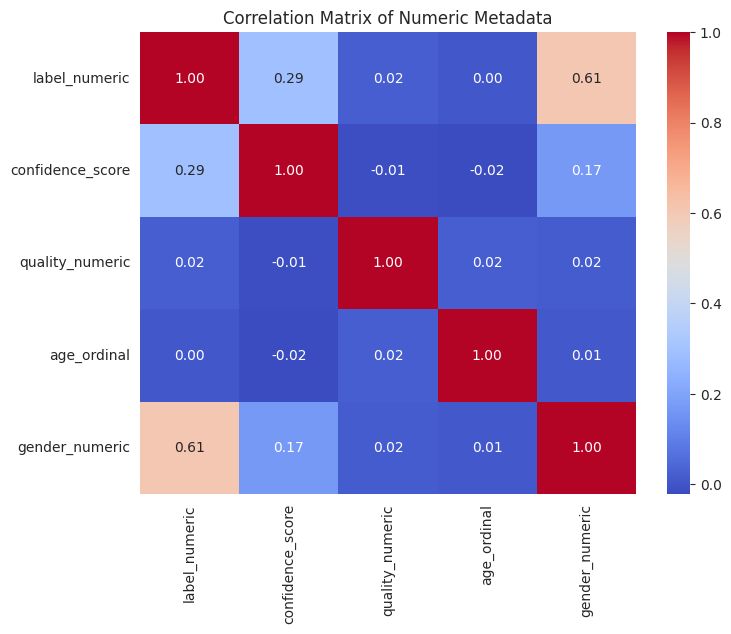

In [25]:
numeric_cols = ['label_numeric']
if 'confidence_score' in df.columns:
    numeric_cols.append('confidence_score')
if 'image_quality_numeric' not in df.columns:
    # create a numeric version if needed
    if 'image_quality' in df.columns:
        df['quality_numeric'] = df['image_quality'].map({'High':2, 'Medium':1, 'Low':0})
        numeric_cols.append('quality_numeric')
if 'age_group_numeric' in df.columns:
    numeric_cols.append('age_group_numeric')
else:
    # map age groups to ordinal
    if 'age_group' in df.columns:
        age_order = {'18-25':1, '26-35':2, '36-50':3, '50+':4}
        df['age_ordinal'] = df['age_group'].map(age_order)
        numeric_cols.append('age_ordinal')
if 'gender_numeric' in df.columns:
    numeric_cols.append('gender_numeric')
else:
    if 'gender' in df.columns:
        df['gender_numeric'] = df['gender'].map({'Male':1, 'Female':2, 'Unknown':0})
        numeric_cols.append('gender_numeric')

# Compute correlation only with existing columns
available_numeric = [c for c in numeric_cols if c in df.columns]
if len(available_numeric) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[available_numeric].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Numeric Metadata')
    plt.show()

